之前写过的sequence (默写)：

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler


In [12]:
import pandas as pd

df = pd.read_csv('airline-passengers.csv')
print(df.info())  # 查看数据类型，是否有缺失


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None


Epoch 0/1000: train MSE 0.653, eval MSE 6.269
Epoch 200/1000: train MSE 0.094, eval MSE 0.915
Epoch 400/1000: train MSE 0.089, eval MSE 0.818
Epoch 600/1000: train MSE 0.085, eval MSE 0.799
Epoch 800/1000: train MSE 0.083, eval MSE 0.754


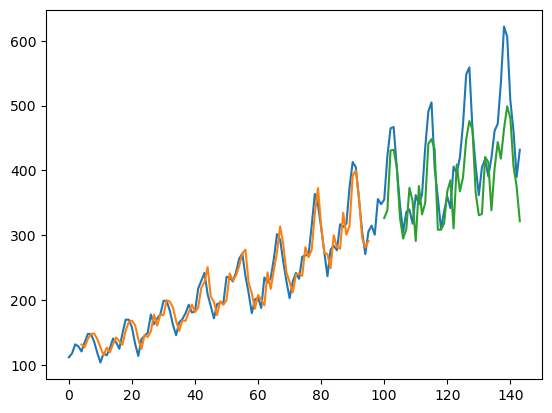

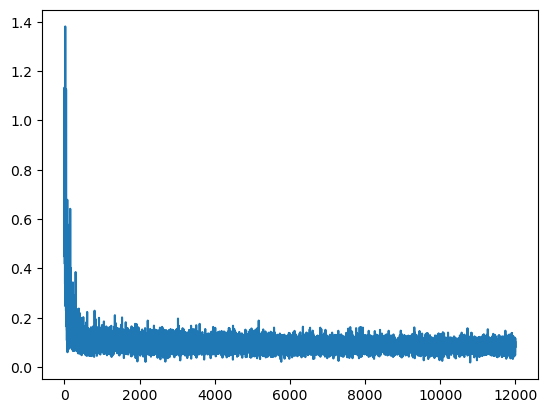

In [27]:
timeseries = df[['Passengers']].values.astype('float32')

total_samples = timeseries.shape[0]
train_size = int(total_samples*0.67)
test_size = total_samples - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

scaler = StandardScaler()
train = scaler.fit_transform(train)
test = scaler.transform(test)

def create_dataset(train, lookback=1):
    X, y = [], []
    total_time = train.shape[0]
    for t in range(total_time-lookback):
        input = train[t:t+lookback]
        target = train[t+1:t+lookback+1] 
        X.append(input)
        y.append(target)

    X, y = np.array(X), np.array(y)

    return torch.tensor(X), torch.tensor(y)

lookback = 4
X_train, y_train = create_dataset(train, lookback)
X_test, y_test = create_dataset(test, lookback)

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=10, batch_first=True)
        self.linear = nn.Linear(10, 1)

    def forward(self, x):
        x, _ = self.rnn(x) # output has seq_len
        x = self.linear(x)
        return x

model = AirModel()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 1000
loss_history = []
# mse_early_stop = 
for epoch in range(epochs):
    model.train()
    for X_train_batch, y_train_batch in loader:
        y_pred = model(X_train_batch)
        loss = loss_fn(y_pred, y_train_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_history.append(loss.detach())

    if epoch % 200 != 0:
        continue

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
        mse_test = loss_fn(y_pred, y_test)
        y_pred = model(X_train)
        mse_train = loss_fn(y_pred, y_train)

        print(f'Epoch {epoch}/{epochs}: train MSE {mse_train:.3f}, eval MSE {mse_test:.3f}')

# plot
with torch.no_grad():
    y_pred = model(X_train)
    y_train_plot = scaler.inverse_transform(y_pred[:, -1, :])
    y_pred = model(X_test)
    y_test_plot = scaler.inverse_transform(y_pred[:, -1, :])

plt.figure()
plt.plot(timeseries)
plt.plot(range(lookback, train_size), y_train_plot)
plt.plot(range(train_size+lookback, total_samples), y_test_plot)

plt.figure()
plt.plot(loss_history)

两层 MLP + 完整训练循环

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [39]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5,10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10,1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

sample_size = 32
inputs = torch.randn(sample_size, 5) # sample size, dimension
targets = torch.ones(sample_size, 1)
idx = torch.randint(0, sample_size, (int(sample_size/2),))
targets[idx] = -1

X_train = inputs
y_train = targets

model = MLP()
optimizer = optim.SGD(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
# if sign(y) neq label, then backward and update weights

n_epochs = 1000
for epoch in range(n_epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 != 0:
        continue

    # model.eval()

    print(f"Epoch {epoch}, loss {loss.detach():.3f}")



Epoch 0, loss 0.955
Epoch 200, loss 0.928
Epoch 400, loss 0.908
Epoch 600, loss 0.892
Epoch 800, loss 0.878


数组操作

In [59]:
import numpy as np

def min_max_scaler(x):

    min, max = np.min(x, axis=0), np.max(x, axis=0)
    print(x.shape, min.shape)

    return (x - min) / (max - min + 1e-6)

a = np.random.randn(8, 5)
print(a)
print(min_max_scaler(a))

[[ 0.7193763   0.86600874 -1.33773793 -1.15129092  1.07484323]
 [ 0.43804708 -0.53344578 -0.36302018  1.82080585 -0.80087724]
 [ 0.29918233 -0.99962769 -0.29561232  1.06426203 -0.44338858]
 [ 0.085176    1.22216011  0.77888655  1.14129478  0.53838981]
 [ 0.617921   -0.21487078  1.16215717 -0.76453665  1.02374547]
 [ 0.1964061   0.3378553   1.14188356 -0.05184932 -1.76732216]
 [ 0.13589951 -1.309069   -0.31606139 -1.10697917  0.17907003]
 [ 0.00825783  0.38592309 -0.46498195  0.68189061 -0.61866977]]
(8, 5) (5,)
[[0.99999859 0.85929672 0.         0.         0.99999965]
 [0.60438403 0.30642146 0.38990331 0.99999966 0.34003812]
 [0.40910778 0.12224938 0.41686757 0.7454509  0.46581846]
 [0.10816491 0.9999996  0.84668498 0.77136955 0.81125158]
 [0.85732875 0.43227924 0.9999996  0.13012838 0.9820212 ]
 [0.26458039 0.65064187 0.99188982 0.36992108 0.        ]
 [0.179494   0.         0.4086876  0.01490925 0.68482697]
 [0.         0.66963177 0.3491169  0.61679718 0.40414678]]


In [47]:
x = np.random.randn(2,3)

x_col_mean = np.mean(x, axis=0)

x_col_normed = (x - np.mean(x, axis=0)) / (np.std(x, axis=0) + 1e-6)

x_row_l2norm = np.linalg.norm(x_col_normed, axis=1)

pos_mean_idx = x_col_mean >= 0
x_pos_mean = x_col_normed[:, pos_mean_idx]

print(x)
print(x_col_mean)
print(x_col_normed)
print(x_row_l2norm)
print(x_pos_mean)

[[ 0.04615507  0.15087427 -0.72542267]
 [-0.84011188  0.16758802  0.42644711]]
[-0.39697841  0.15923114 -0.14948778]
[[ 0.99999774 -0.99988035 -0.99999826]
 [-0.99999774  0.99988035  0.99999826]]
[1.73197943 1.73197943]
[[-0.99988035]
 [ 0.99988035]]


In [53]:
import torch

x = torch.randn(8, 5)

batch_mean = torch.mean(x, axis=0)

l2norm = torch.norm(x, dim=1)

x_col3 = x[:, 2]

lin_w = torch.randn(5, 1)
lin_b = torch.randn(1)
y = x @ lin_w + lin_b
print(x @ lin_w, lin_b)
print(y)


tensor([[ 1.7718],
        [-1.0558],
        [ 3.3329],
        [ 1.0247],
        [ 0.6023],
        [ 0.0888],
        [ 0.2764],
        [ 0.5424]]) tensor([-0.8094])
tensor([[ 0.9624],
        [-1.8653],
        [ 2.5235],
        [ 0.2153],
        [-0.2071],
        [-0.7207],
        [-0.5330],
        [-0.2671]])


In [54]:
x = torch.randn(32, 10)
w = torch.randn(10)

# 行乘
y = x * w   # torch 自动把 w 看成 (1,10)，再扩展成 (32,10), 然后进行逐元素相乘
print(y.shape)

torch.Size([32, 10])


In [58]:
x = torch.randn(32, 10)

x_np = x.detach().numpy()
x_np = np.array(x.detach())
type(x_np)

numpy.ndarray